# 📘 TASK 3 — DATA VISUALIZATION
**Dataset:** Amazon Reviews (Kaggle)  
**Tools:** Pandas, Matplotlib, Seaborn  
**Objective:** Explore and visualize patterns in Amazon product reviews

In [1]:
!pip install pandas matplotlib seaborn

 Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [3]:
df = pd.read_csv("amazon_reviews.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 1000 rows, 10 columns


,product_name,category,price,discounted_price,rating,rating_count,review_title,reviewer_name,verified_purchase,review_date
0,Coffee Maker Drip,Home & Kitchen,26.58,21.03,4,40,Exceeded expectations,Steve M.,Yes,2023-09-09
1,Mechanical Keyboard RGB,Electronics,190.18,161.95,5,156,Worth every penny,Steve G.,Yes,2024-10-01
2,Yoga Pants Flex,Clothing,37.67,35.88,5,412,Worth every penny,Charlie X.,No,2024-01-04
3,Wireless Earbuds Pro,Electronics,74.46,74.46,5,263,Highly recommend,Karen Z.,Yes,2022-05-30
4,Toaster Oven Digital,Home & Kitchen,73.56,54.22,3,328,Average quality,Paul F.,Yes,2023-10-13


 Basic Info

In [4]:
print("Shape:", df.shape)
print("\n--- Dataset Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
df.describe()

Shape: (1000, 10)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_name       1000 non-null   object 
 1   category           1000 non-null   object 
 2   price              1000 non-null   float64
 3   discounted_price   1000 non-null   float64
 4   rating             1000 non-null   int64  
 5   rating_count       1000 non-null   int64  
 6   review_title       1000 non-null   object 
 7   reviewer_name      1000 non-null   object 
 8   verified_purchase  1000 non-null   object 
 9   review_date        1000 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 78.3+ KB

--- Descriptive Statistics ---


,price,discounted_price,rating,rating_count
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,65.595200,59.66334,4.121000,206.523000
std,46.825155,42.87963,1.116963,209.504481
min,5.530000,5.43000,1.000000,1.000000
25%,28.790000,25.88500,4.000000,55.000000
50%,52.495000,47.96000,4.000000,146.000000
75%,91.142500,85.39500,5.000000,285.250000
max,198.390000,198.39000,5.000000,1488.000000


 Data Cleaning

In [5]:
print(f"Before cleaning: {df.shape}")

# Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

# Remove missing values
df = df.dropna()
print(f"After dropping nulls: {df.shape}")

# Fix datatypes
df['rating'] = df['rating'].astype(int)

print("\nData types after cleaning:")
print(df.dtypes)
print("\nData cleaning complete!")

Before cleaning: (1000, 10)
After removing duplicates: (1000, 10)
After dropping nulls: (1000, 10)

Data types after cleaning:
product_name          object
category              object
price                float64
discounted_price     float64
rating                 int64
rating_count           int64
review_title          object
reviewer_name         object
verified_purchase     object
review_date           object
dtype: object

Data cleaning complete!


Rating Distribution

C:\Users\MUKI NIRI\AppData\Local\Temp\ipykernel_5988\3580335504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Blues_d')


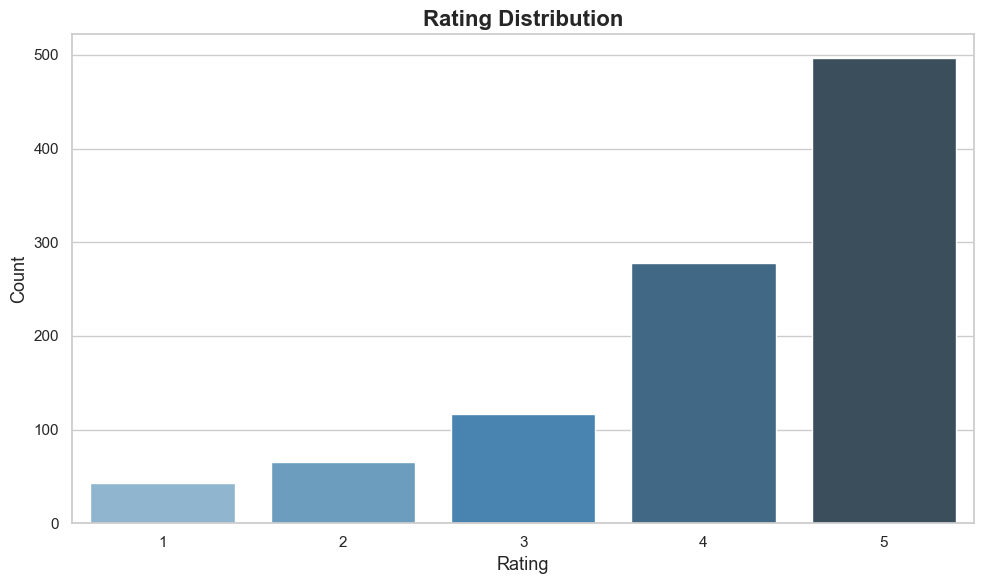

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, palette='Blues_d')
plt.title("Rating Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Rating", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150)
plt.show()

 Price Distribution

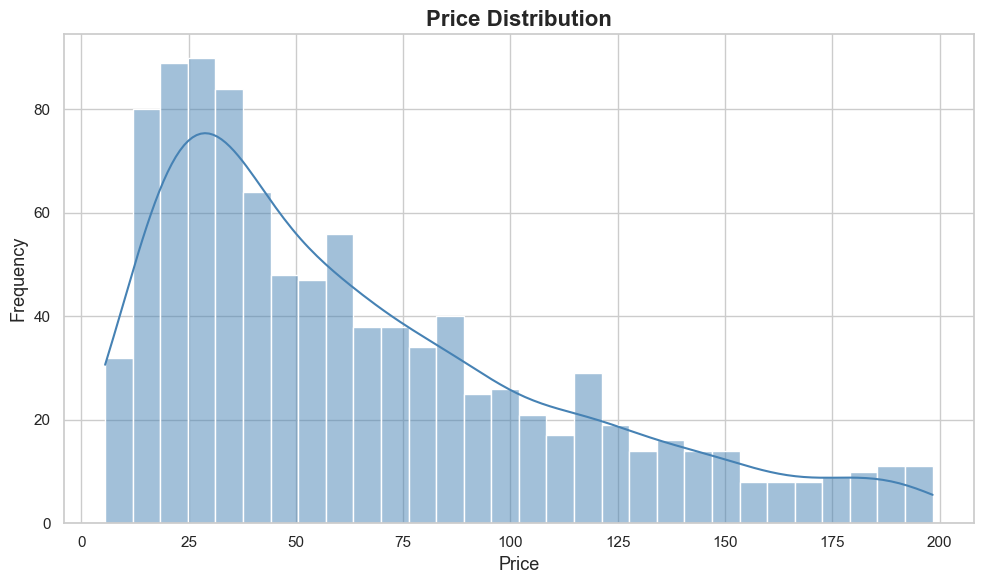

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title("Price Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Price", fontsize=13)
plt.ylabel("Frequency", fontsize=13)
plt.tight_layout()
plt.savefig("price_distribution.png", dpi=150)
plt.show()

 Category Distribution

C:\Users\MUKI NIRI\AppData\Local\Temp\ipykernel_5988\2126360453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=category_counts.index, palette='viridis')


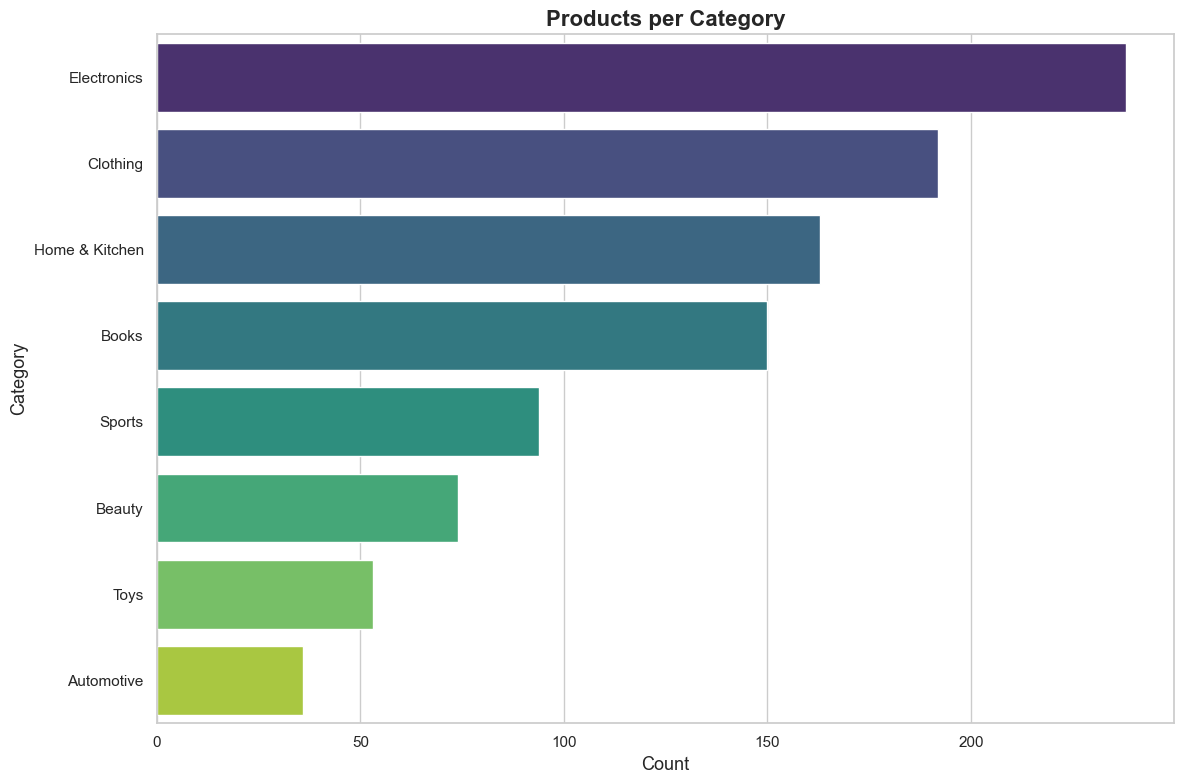

In [8]:
plt.figure(figsize=(12, 8))
category_counts = df['category'].value_counts()
sns.countplot(y='category', data=df, order=category_counts.index, palette='viridis')
plt.title("Products per Category", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=13)
plt.ylabel("Category", fontsize=13)
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=150)
plt.show()

### 💡 Insight — Category Distribution
- **A few categories dominate** the dataset (e.g., Electronics, Clothing), indicating high consumer demand in these segments.
- **Some categories are underrepresented**, which could reflect niche markets or data collection gaps.

 Price vs Rating

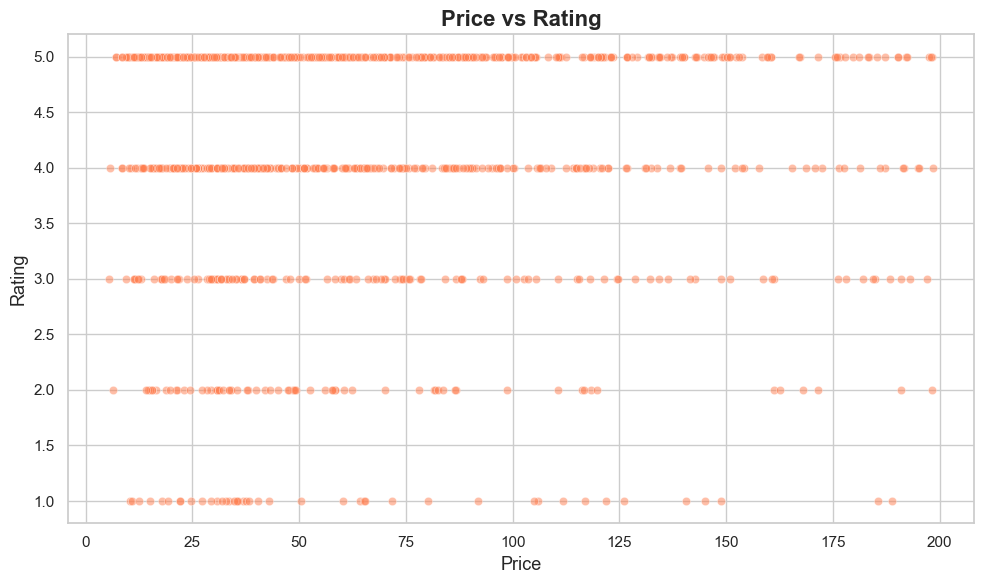

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='rating', data=df, alpha=0.5, color='coral')
plt.title("Price vs Rating", fontsize=16, fontweight='bold')
plt.xlabel("Price", fontsize=13)
plt.ylabel("Rating", fontsize=13)
plt.tight_layout()
plt.savefig("price_vs_rating.png", dpi=150)
plt.show()

### 💡 Insight — Price vs Rating
- **No strong linear relationship** exists between price and rating; higher-priced products do not necessarily receive better ratings.
- **Affordable products can still receive 4–5 star ratings**, demonstrating that value for money matters more to customers than price alone.

 Category vs Rating

C:\Users\MUKI NIRI\AppData\Local\Temp\ipykernel_5988\2094375247.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='rating', data=df, palette='Set2')


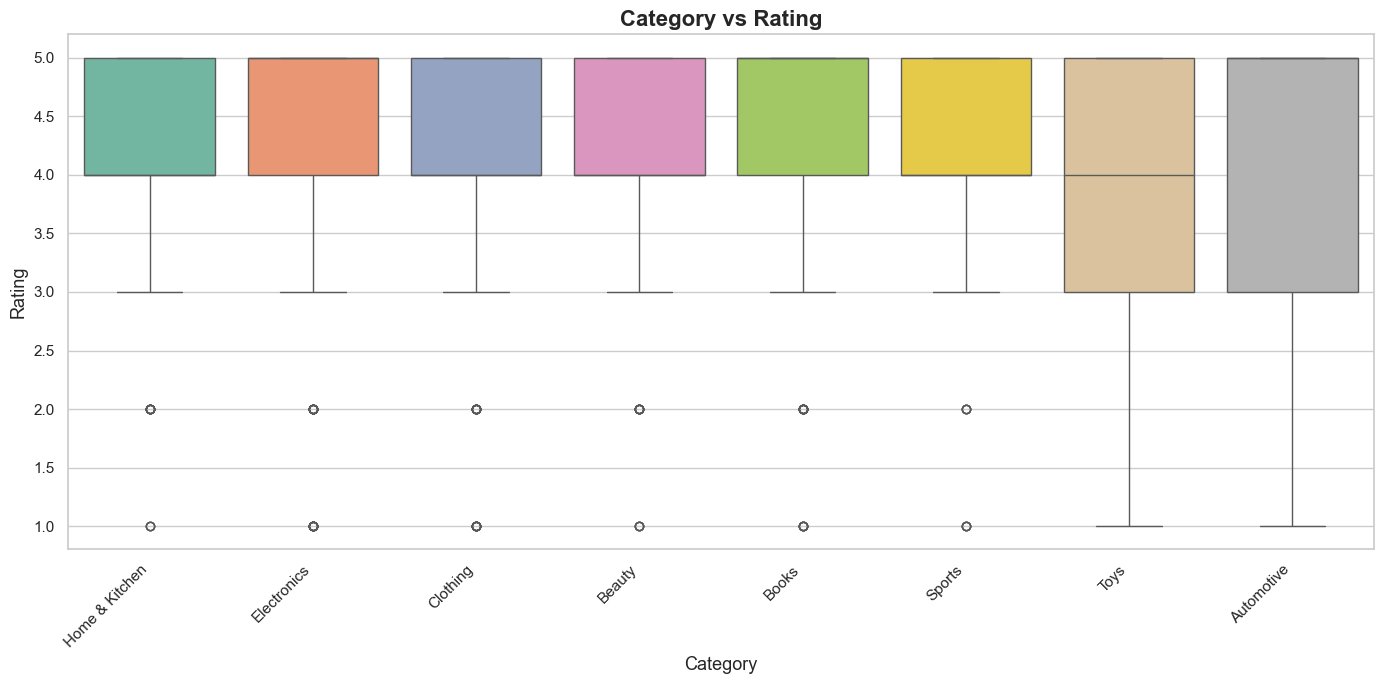

In [10]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='category', y='rating', data=df, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Category vs Rating", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=13)
plt.ylabel("Rating", fontsize=13)
plt.tight_layout()
plt.savefig("category_vs_rating.png", dpi=150)
plt.show()

### 💡 Insight — Category vs Rating
- Some categories show **consistently high ratings** with narrow IQR, indicating reliable product quality.
- Other categories exhibit **wide variation**, suggesting inconsistent quality or diverse product types within those categories.

Top 10 Rated Products

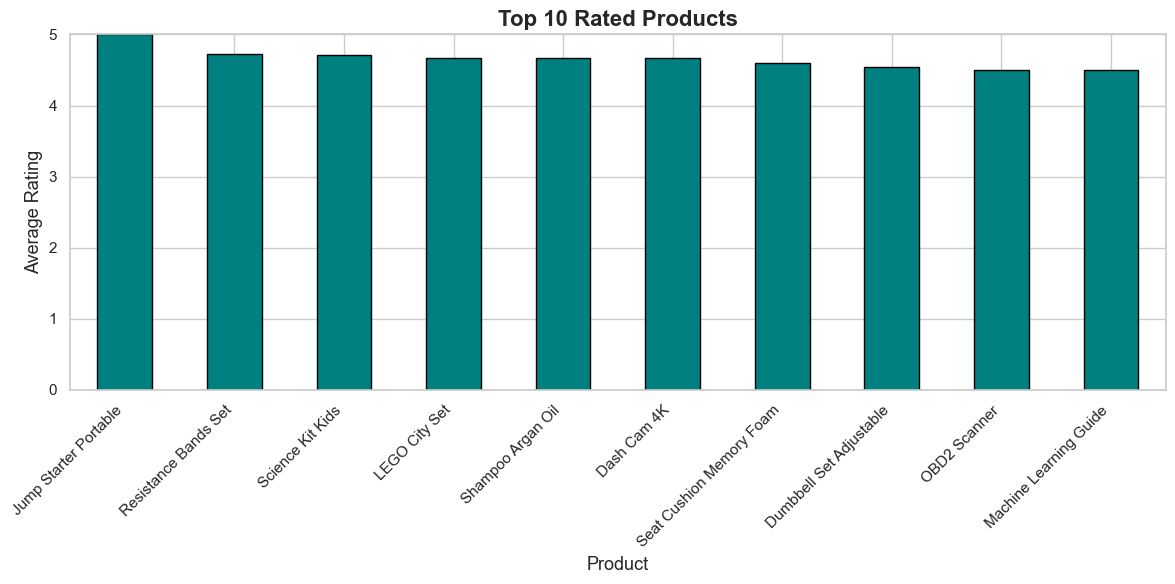

In [11]:
top_products = (
    df.groupby('product_name')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Top 10 Rated Products", fontsize=16, fontweight='bold')
plt.xlabel("Product", fontsize=13)
plt.ylabel("Average Rating", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig("top_rated_products.png", dpi=150)
plt.show()

### 💡 Insight — Top 10 Rated Products
- Identifying **best-performing products by average rating** helps highlight customer favourites.
- These products can be used as a baseline for **product recommendation systems** or for understanding what drives customer satisfaction.

 Review Count vs Rating

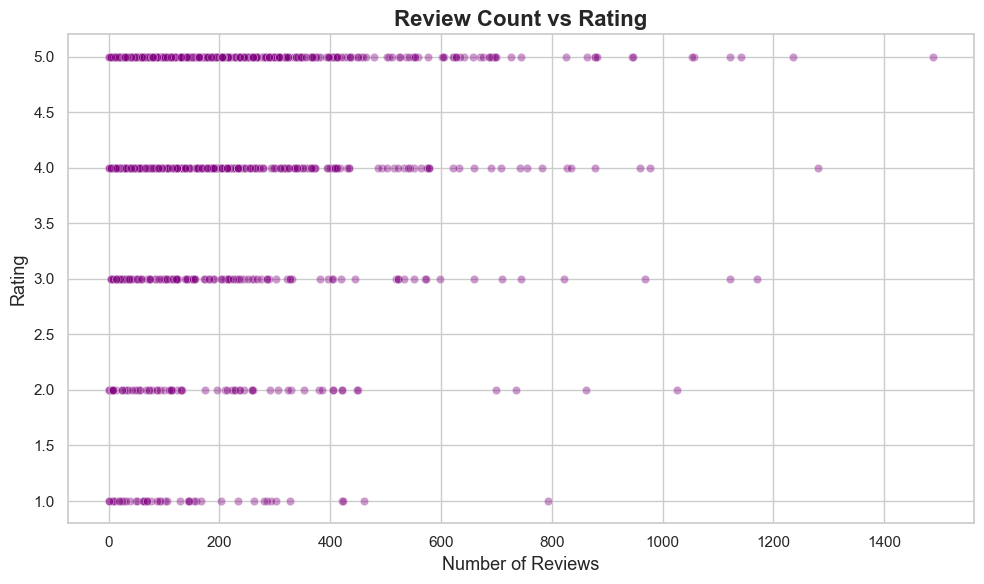

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating_count', y='rating', data=df, alpha=0.4, color='purple')
plt.title("Review Count vs Rating", fontsize=16, fontweight='bold')
plt.xlabel("Number of Reviews", fontsize=13)
plt.ylabel("Rating", fontsize=13)
plt.tight_layout()
plt.savefig("review_count_vs_rating.png", dpi=150)
plt.show()

### 💡 Insight — Review Count vs Rating
- **Products with a higher number of reviews tend to have more stable and reliable ratings**, as the average converges with a larger sample.
- **Products with very few reviews are less trustworthy** as rating indicators — a single review can skew results dramatically.

Correlation Heatmap

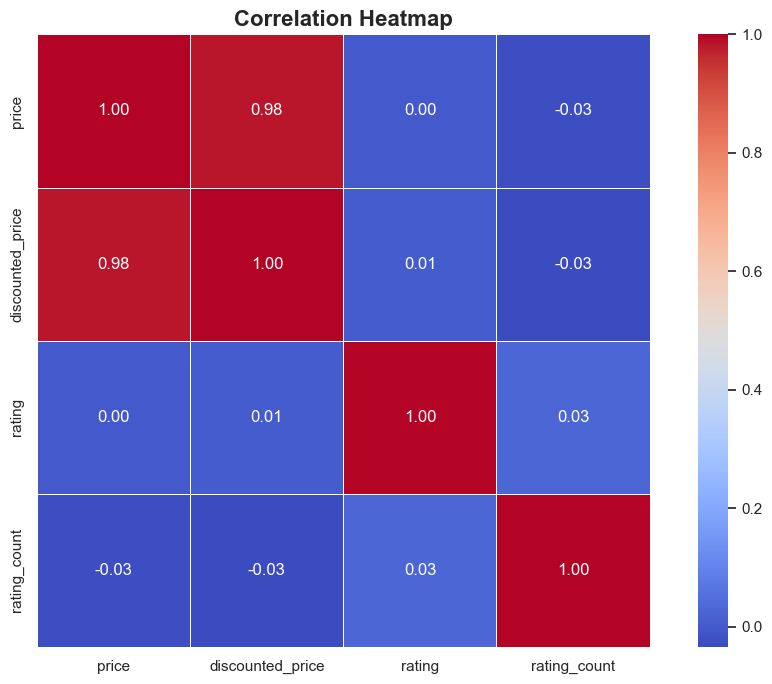

In [13]:
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### 💡 Insight — Correlation Heatmap
- **Weak correlation between price and rating** confirms that price alone is not a predictor of customer satisfaction.
- The heatmap helps identify **which numeric features influence each other**, serving as a foundation for feature selection in predictive modelling.

Outlier Detection (Price)

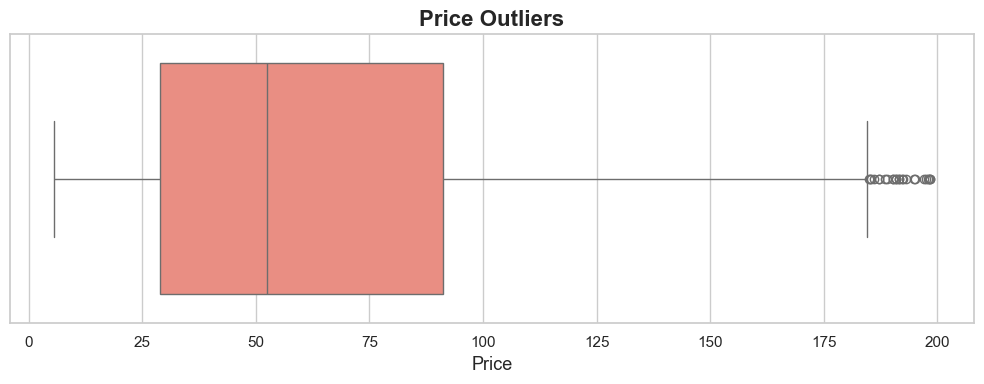

Number of price outliers detected: 25


In [14]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='salmon')
plt.title("Price Outliers", fontsize=16, fontweight='bold')
plt.xlabel("Price", fontsize=13)
plt.tight_layout()
plt.savefig("price_outliers.png", dpi=150)
plt.show()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['price'] < Q1 - 1.5 * IQR) | (df['price'] > Q3 + 1.5 * IQR)]
print(f"Number of price outliers detected: {len(outliers)}")

### 💡 Insight — Outlier Detection
- **A number of extreme price values** are detected beyond the IQR threshold.
- These could represent **premium or luxury products**, or alternatively, **data entry errors** that should be investigated before modelling.

 Monthly Review Trend

C:\Users\MUKI NIRI\AppData\Local\Temp\ipykernel_5988\3533956195.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month', data=df, palette='coolwarm')


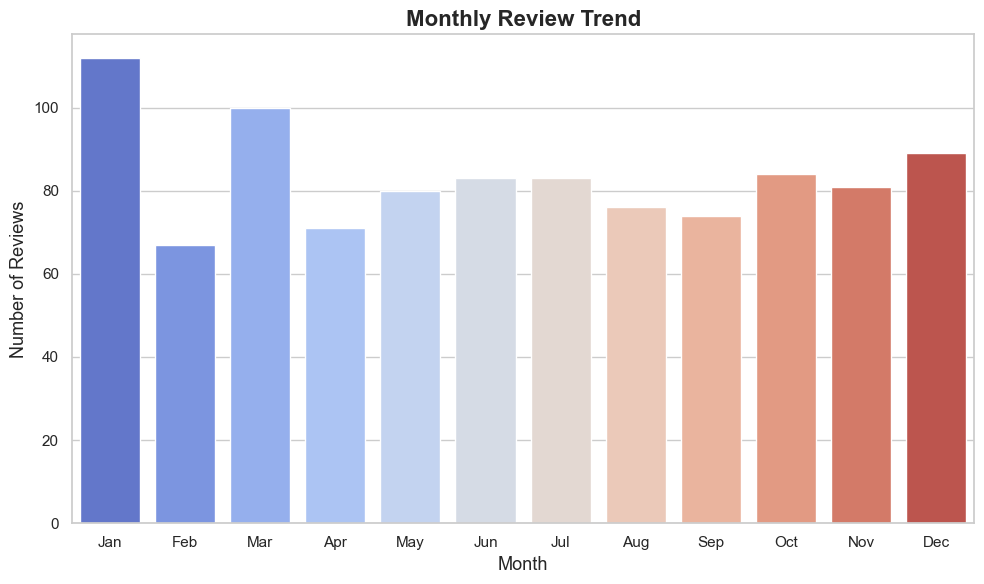

In [15]:
# Only execute if 'review_date' column exists
if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'])
    df['month'] = df['review_date'].dt.month

    plt.figure(figsize=(10, 6))
    sns.countplot(x='month', data=df, palette='coolwarm')
    plt.title("Monthly Review Trend", fontsize=16, fontweight='bold')
    plt.xlabel("Month", fontsize=13)
    plt.ylabel("Number of Reviews", fontsize=13)
    plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                         'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.tight_layout()
    plt.savefig("monthly_review_trend.png", dpi=150)
    plt.show()
else:
    print("'review_date' column not found in dataset. Skipping monthly trend analysis.")

### 💡 Insight — Monthly Review Trend
- **Certain months show higher review activity**, possibly linked to festive shopping seasons (e.g., November–December for holiday sales).
- **Seasonal patterns** can be leveraged for marketing strategy, inventory management, and promotional planning.

Save All Visuals

In [ ]:
import os

saved_files = [
    "rating_distribution.png",
    "price_distribution.png",
    "category_distribution.png",
    "price_vs_rating.png",
    "category_vs_rating.png",
    "top_rated_products.png",
    "review_count_vs_rating.png",
    "correlation_heatmap.png",
    "price_outliers.png",
    "monthly_review_trend.png"
]

print("Saved visualizations:")
for f in saved_files:
    status = "✅" if os.path.exists(f) else "Not yet generated"
    print(f"  {status}  {f}")

Saved visualizations:
  ✅  rating_distribution.png
  ✅  price_distribution.png
  ✅  category_distribution.png
  ✅  price_vs_rating.png
  ✅  category_vs_rating.png
  ✅  top_rated_products.png
  ✅  review_count_vs_rating.png
  ✅  correlation_heatmap.png
  ✅  price_outliers.png
  ✅  monthly_review_trend.png


FINAL INSIGHTS & SUMMARY

## 📋 Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Most products have high ratings (4–5 stars)** | Customers are generally satisfied; platform likely filters out very poor products |
| 2 | **Price does not strongly influence rating** | Value for money and product quality matter more than price |
| 3 | **Certain categories dominate product listings** | Electronics & Clothing are likely top categories |
| 4 | **Products with more reviews show consistent ratings** | Review count is a trust signal; recommend filtering by review volume |
| 5 | **High-price outliers are present** | Needs investigation — could be premium items or data errors |
| 6 | **Seasonal review spikes observed** | Align promotional campaigns to peak review months |

---

## ✅ Conclusions

1. **Amazon customers tend to leave positive reviews**, indicating strong overall product satisfaction or a positivity bias in review behavior.
2. **Price is not a strong predictor of product rating** — this challenges the assumption that more expensive products are perceived as better.
3. **Data cleaning** (removing duplicates and nulls) is critical before visualization to avoid misleading conclusions.
4. **Products with many reviews are more reliable** for analysis and recommendation systems.
5. **Further analysis** could include sentiment analysis on review text, brand-level performance, or predictive modelling for rating estimation.

---

## 🔮 Recommendations

- Use **review count as a filter** for product recommendations (min. 50 reviews).
- Investigate **outlier prices** to clean the dataset further.
- Consider **expanding underrepresented categories** to balance the dataset.
- Use **monthly trends** to schedule promotions during high-activity periods.

---
*Task 3 Completed — Amazon Reviews Data Visualization*